# FLEURS Dataset Exploration

## 1  Overview

This notebook explores the FLEURS dataset before evaluating the speech-to-text (Whisper) models. FLEURS (Few-shot Learning Evaluation of Universal Representations of Speech) is a multilingual speech corpus, comprising parallel spoken recordings with reference transcriptions in numerous languages [1].

The project supports four languages English, Malay, Chinese and Tamil and therefore the exploration is focused on these four FLEURS configurations. The goal is to learn about the data before applying it the splits provided and their sizes, the metadata columns, the quality of the transcriptions and audio, and the technical properties of the recordings (sample rate, channels, format and duration).

As the project uses pre-trained speech models and does no training or fine-tuning, FLEURS is used only for evaluation. We select a fixed and reproducible subset of recordings per language, save the audio files and reference transcriptions for the Whisper evaluation notebook, and leave the original dataset unchanged.

## 2  Importing Libraries

The analysis uses pathlib for file paths, pandas for tabular summaries, matplotlib for the distribution plots, soundfile to examine audio properties and unicodedata to normalize transcriptions. The FLEURS splits are loaded directly by the Hugging Face datasets library and IPython.display. The notebook contains audio that allows a sample recording to be played.

In [1]:
# Importing required libraries
from pathlib import Path
import pandas as pd
import io
import matplotlib.pyplot as plt
import soundfile as sf
import unicodedata
from datasets import Audio, load_dataset
from IPython.display import Audio as IPythonAudio, display

c:\Users\Subathra\OneDrive\Desktop\CM3020_Solace_Wellbeing_Monitoring\CM3020_Solace_Wellbeing_Monitoring_FYP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# remove all warnings
import os
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_VERBOSITY"] = "error"

import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

## 3  Loading the Dataset

FLEURS is directly loaded from the Hugging Face Hub. A fixed random seed is set so that the sample selection is reproducible later. A fixed number of recordings per language (SAMPLES_PER_LANGUAGE) is set so that every language contributes the same amount of evaluation data. The four languages are each mapped to its FLEURS config code and corresponding Whisper language code.

In [3]:
# reproducible selection
SEED = 42

In [4]:
# number of recordings per language in model evaluation
SAMPLES_PER_LANGUAGE = 200

In [5]:
# FLEURS dataset
DATASET_ID = "google/fleurs"

In [6]:
# languages used in the project
languages = {
    "English": {
        "fleurs_config": "en_us",
        "whisper_language": "en"
    },
    "Malay": {
        "fleurs_config": "ms_my",
        "whisper_language": "ms"
    },
    "Chinese": {
        "fleurs_config": "cmn_hans_cn",
        "whisper_language": "zh"
    },
    "Tamil": {
        "fleurs_config": "ta_in",
        "whisper_language": "ta"
    }
}

In [7]:
# dictionaries for validation and testing
validation_datasets = {}
testing_datasets = {}

For every language, the original validation and test splits are loaded. In order to maintain quick loading times and minimal memory usage, audio decoding is deferred (decode=False), allowing the raw audio bytes to be examined and stored without being decoded into arrays during load time.

In [8]:
# original FLEURS validation and test splits
for language, details in languages.items():
    validation_datasets[language] = load_dataset(DATASET_ID, details["fleurs_config"], split="validation").cast_column("audio", Audio(decode=False))
    testing_datasets[language] = load_dataset(DATASET_ID, details["fleurs_config"], split="test").cast_column("audio", Audio(decode=False))

In [9]:
# number of records each original split
split_results = []

In [10]:
# append to the split result list
for language in languages:
    split_results.append({"Language": language,
                          "Validation Records": len(validation_datasets[language]),
                          "Testing Records": len(testing_datasets[language])
                         })

In [11]:
# df split dataframe
df_splits = pd.DataFrame(split_results)
df_splits

,Language,Validation Records,Testing Records
0,English,394,647
1,Malay,324,749
2,Chinese,409,945
3,Tamil,377,591


**Analysis:** 

For all four languages, FLEURS offers sizable, pre-made validation and test splits. However, the quantities vary significantly between languages. Chinese has the most recordings (945) in the **test** split, followed by Malay (749), English (647), and Tamil (591). The validation split is smaller overall (409 Chinese, 394 English, 377 Tamil, 324 Malay). The next two points are as follows.

First, because these totals are comfortably greater than the actual number needed for evaluation, it is possible to draw a fixed, equal-sized sample for each language instead of using every recording as a crucial step for a fair cross-language comparison. Otherwise, Chinese would be over-represented just because it has more data.

Second, the two divides maintain their original functions the test split is set aside for the final assessment of the selected model, while the validation split is used to compare and choose the speech model. The model will not be chosen and reported on the same data if they are kept separate.

## 4  Understanding the Dataset Structure

Each FLEURS dataset's metadata columns and a preview of its transcriptions are inspected before any records are chosen in order to verify that the data was imported correctly and to determine which fields are relevant to voice recognition.

In [12]:
# columns available in each FLEURS dataset
for language in languages:
    print(language, validation_datasets[language].column_names)

English ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id']
Malay ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id']
Chinese ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id']
Tamil ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id']


In [13]:
# display first five validation transcriptions for each language
for language, dataset in validation_datasets.items():
    print(f"\n{language}")
    # sample records
    sample_records = pd.DataFrame({"Transcription": [dataset[index]["transcription"] for index in range(min(5, len(dataset)))]})
    display(sample_records)


English


,Transcription
0,when you call someone who is thousands of mile...
1,now widely available throughout the archipelag...
2,the u.n. also hopes to finalize a fund to help...
3,then lakkha singh took the lead in singing the...
4,the major religion in moldova is orthodox chri...



Malay


,Transcription
0,saya tidak tahu kalau anda sedar tetapi kebany...
1,penyelidikan dalam al melibatkan pembuatan mes...
2,pandangan yang dibentangkan biasanya sepintas ...
3,banyak format biasa contohnya format dari kelu...
4,sebahagian besar kehidupan keluarga ibrani ber...



Chinese


,Transcription
0,报 告 警 告 称 没 有 人 能 保 证 目 前 在 伊 拉 克 采 取 的 任 何 行 ...
1,因 为 远 离 大 陆 哺 乳 动 物 无 法 长 途 跋 涉 而 来 使 得 巨 龟 成 ...
2,亚 马 逊 河 也 是 地 球 上 最 宽 的 河 流 有 些 河 段 的 宽 度 可 达 ...
3,迦 南 没 有 大 森 林 所 以 木 材 非 常 昂 贵
4,据 警 方 称 撞 倒 摄 影 师 的 汽 车 司 机 未 必 会 面 临 刑 事 指 控



Tamil


,Transcription
0,இந்த விதிகள் திருத்தப்படுவதற்கு முன்னர் அனைத்த...
1,"""கருத்து கேட்டபோது ""விசாரணையின் போது மைக் அதிக..."
2,பூச்சிகளே காற்றில் பறந்த முதல் விலங்குகள் அவற்...
3,சுற்றுச்சூழலுடன் நாம் மிகவும் இணக்கமாக வாழத் த...
4,பல மாவட்டங்கள் சிறிய வசதியான பலமான ஜப்பானிய கோ...


**Analysis:** 

The fact that all four languages had the same set of metadata columns indicates that the configurations were loaded consistently. The parameters audio (the recording) and **transcription** (the reference text Whisper output is graded against) are pertinent to this project. raw_transcription maintains the original punctuation and casing, whereas transcription has already undergone some normalization. Although they provide helpful background, the remaining elements (id, num_samples, path, gender, lang_id, language, lang_group_id) are not required for the word-error-rate assessment. The same processing code can be used for all four languages without focusing in any one of them due to confirmation of this consistent structure across languages.

## 5  Sample Recording

A single English validation recording is decoded in memory and played inside the notebook together with its reference transcription, to confirm that the raw audio bytes can be retrieved and are playable. Nothing is written to disk the sample exists only for this quick sanity check which keeps the exploration free of stray files while still proving that acceptable audio is preserved by the deferred decoding method.

In [14]:
# first English validation recording
sample = validation_datasets["English"][0]

In [15]:
# audio information
audio_information = sample["audio"]

In [16]:
# decode the sample audio in memory (no file is written to disk)
waveform, sample_rate = sf.read(io.BytesIO(audio_information["bytes"]))

In [17]:
# print the transcription and the sample's basic audio properties
print("Transcription:", sample["transcription"])
print("Sample rate:", sample_rate, "Hz")
print("Duration:", round(len(waveform) / sample_rate, 2), "seconds")

Transcription: when you call someone who is thousands of miles away you are using a satellite
Sample rate: 16000 Hz
Duration: 6.54 seconds


In [18]:
# play the sample recording inline from the decoded array
IPythonAudio(data=waveform, rate=sample_rate)

**Analysis:** 

The transcription "when you call someone who is thousands of miles away you are using a satellite" reads as clear, well-formed English that corresponds with the audio, and the sample was decoded in memory and played correctly without saving any file. This simultaneously verifies that the transcription field holds logical reference text, that the raw audio bytes are intact and playable, and that the pairing between a recording and its transcription is accurate. Establishing this on a single sample, without leaving any artefact on disk, provides assurance before the same extraction is applied at scale in Section 9.

## 6  Split and Language Distribution

In order to clearly notice the imbalance between languages in the raw dataset and take it into consideration when choosing evaluation samples, the complete validation and test counts for each language are recorded and shown.

In [19]:
# validation and testing counts
distribution = pd.DataFrame({
    "Validation": {
        language: len(dataset)
        # for each validation set
        for language, dataset
        in validation_datasets.items()
    },
    "Testing": {
        language: len(dataset)
        # for each testing
        for language, dataset
        in testing_datasets.items()
    }
})

In [20]:
# distribution dataframe
distribution

,Validation,Testing
English,394,647
Malay,324,749
Chinese,409,945
Tamil,377,591


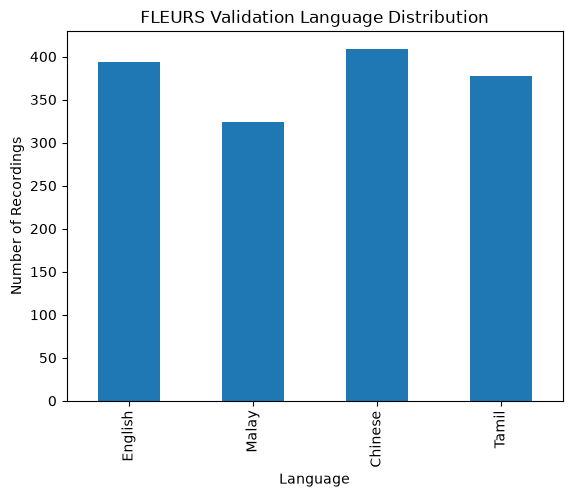

In [21]:
# validation distribution
distribution["Validation"].plot(kind="bar")
plt.title("FLEURS Validation Language Distribution")
plt.xlabel("Language")
plt.ylabel("Number of Recordings")
plt.show()

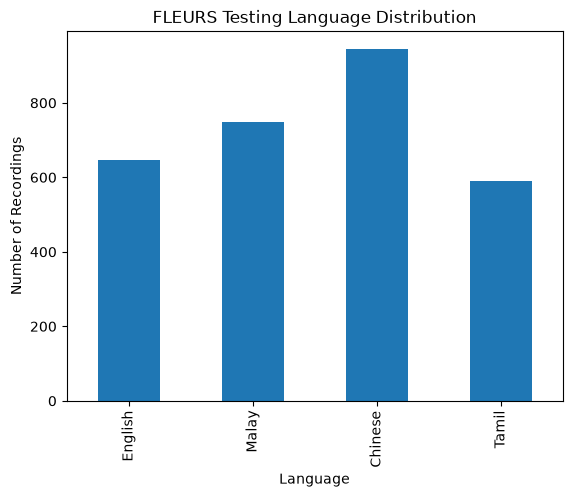

In [22]:
# testing distribution
distribution["Testing"].plot(kind="bar")
plt.title("FLEURS Testing Language Distribution")
plt.xlabel("Language")
plt.ylabel("Number of Recordings")
plt.show()

**Analysis:** 

The cross-language imbalance is evident in the bar charts, where the validation ranges from 324 (Malay) to 409 (Chinese) while the raw test split ranges from 591 (Tamil) to 945 (Chinese). Each language would contribute a different amount of recordings to any pooled outcome if the models were evaluated directly on these raw divides. Therefore, a language with more data (Chinese) would carry more weight than one with less (Tamil). This imbalance is the direct reason for drawing a equal, fixed-size sample per language in Section 8 instead of evaluating on the uneven raw splits, since the objective is a balanced, per-language comparison of transcription accuracy and fairness across the four supported languages is a fundamental concern of this project.

## 7  Metadata and Transcript Quality

Every language and split is examined for audio quality and transcription errors, including missing audio, duplicate transcriptions, empty transcriptions, and missing transcriptions. These verifications ensure that repetitive or incomplete records do not impact the speech-recognition assessment.

In [23]:
# list for transcript checks
checks = []

In [24]:
for language in languages:
    for split_name, dataset in [("Validation",validation_datasets[language]), ("Testing", testing_datasets[language])]:
        # transcriptions
        transcriptions = pd.Series(dataset["transcription"], dtype="object")
        # missing transcripts
        missing_transcriptions = (transcriptions.isnull().sum())
        # empty_transcriptions
        empty_transcriptions = (transcriptions.fillna("").astype(str).str.strip().eq("").sum())
        # duplicated trascriptions
        duplicated_transcriptions = (transcriptions.duplicated().sum())
        # missing audio
        missing_audio = sum(sample["audio"] is None for sample in dataset)
        # append to checks
        checks.append({
            "Language": language,
            "Split": split_name,
            "Missing Transcriptions": missing_transcriptions,
            "Empty Transcriptions": empty_transcriptions,
            "Duplicated Transcriptions": duplicated_transcriptions,
            "Missing Audio": missing_audio
        })

In [25]:
# dataframe for checks
df_checks = pd.DataFrame(checks)
df_checks

,Language,Split,Missing Transcriptions,Empty Transcriptions,Duplicated Transcriptions,Missing Audio
0,English,Validation,0,0,244,0
1,English,Testing,0,0,297,0
2,Malay,Validation,0,0,182,0
3,Malay,Testing,0,0,412,0
4,Chinese,Validation,0,0,259,0
5,Chinese,Testing,0,0,596,0
6,Tamil,Validation,0,0,227,0
7,Tamil,Testing,0,0,255,0


**Analysis:** 

Every recording includes acceptable audio matched with a reference transcription exactly what a word-error-rate evaluation needs because there are no missing transcriptions, no empty transcriptions, and no missing audio in any language or split. However, a significant number of duplicated transcriptions was found in the checks 596 in the Chinese test split, 412 in the Malay test split, and 244 in the English validation split.

The evaluation does not just take the first N recordings of each split because of this significant discovery. If the sample is taken from the top of the file, it may overrepresent a few repeated sentences and provide an inaccurate image of transcription accuracy. Duplicated transcriptions indicate that the same sentence is read by multiple speakers. The mitigation is to shuffle with a predetermined seed before selecting (Section 8), which distributes the selection throughout the whole split and lessens the likelihood that repeated sentences would dominate the assessment sample while maintaining reproducibility. No records are removed since the dataset is solely used for evaluation and duplication is a feature of FLEURS.

## 8  Selecting the Evaluation Samples

For every language, a consistent, repeatable subset of recordings is selected. To ensure that each language contributes an equal number of validation and testing recordings to the assessment, each split is shuffled using the fixed seed and the first SAMPLES_PER_LANGUAGE recordings are taken.

In [26]:
# select the same reproducible evaluation recordings
validation_selected = {}
testing_selected = {}

In [27]:
for language in languages:
    # validation dataset
    validation_dataset = (validation_datasets[language].shuffle(seed=SEED))
    # testing dataset
    testing_dataset = (testing_datasets[language].shuffle(seed=SEED))
    # validation selected language
    validation_selected[language] = (validation_dataset.select(range(min(SAMPLES_PER_LANGUAGE, len(validation_dataset)))))
    # testing selected language
    testing_selected[language] = (testing_dataset.select(range(min(SAMPLES_PER_LANGUAGE, len(testing_dataset)))))

In [28]:
# selected evaluation counts
evaluation_split = []

In [29]:
for language in languages:
    # evaluation split append the records
    evaluation_split.append({
        "Language": language,
        "Validation Records": len(validation_selected[language]),
        "Testing Records": len(testing_selected[language])
    })

In [30]:
# df evaluation dataframe
df_evaluation = pd.DataFrame(evaluation_split)
df_evaluation

,Language,Validation Records,Testing Records
0,English,200,200
1,Malay,200,200
2,Chinese,200,200
3,Tamil,200,200


**Analysis:** 

The selection yields precisely 200 validation and 200 testing recordings for each language, resulting in a perfectly balanced evaluation set of 1,600 recordings overall (4 languages x 2 splits x 200). The notebook's primary design choice is this balance since each language now makes an equal contribution, any variation in assessed transcription accuracy between languages represents the model's real behavior on that language rather than an imitation of one language having more data. Because the shuffle comes before the selection, the duplicated-transcription problem noted in Section 7 is dispersed rather than concentrated at the beginning of the file, and using the fixed seed for the shuffle ensures that re-running the notebook selects the same 200 recordings each time, making the evaluation fully reproducible.

## 9  Saving the Evaluation Audio Files

In order to prevent the Whisper evaluation notebook from having to download and pick the recordings again, the chosen recordings are put to disk in a per-language, per-split folder structure. The language, split, audio path, and transcription are all retained in each saved record. The existence and readability of each saved file are then confirmed.

In [31]:
# folder used by Whisper evaluation
processed_folder = Path("../../data/processed/fleurs_whisper")
processed_folder.mkdir(parents=True, exist_ok=True)

In [32]:
# save selected FLEURS recordings
def save_selected_audio(dataset, language, split_name):
    # config
    config = languages[language]["fleurs_config"]
    # languague folder
    language_folder = (processed_folder / split_name / config)
    language_folder.mkdir(parents=True, exist_ok=True)
    # records list
    records = []
    for index, sample in enumerate(dataset):
        # audio information
        audio_information = (sample["audio"])
        # original path
        original_path = Path(audio_information["path"])
        # suffix for the audio
        suffix = (original_path.suffix if original_path.suffix else ".wav")
        # audio path
        audio_path = (language_folder / f"{index:04d}{suffix}")
        if not audio_path.exists():
            # open the audio
            with open(audio_path, "wb") as audio_file:
                audio_file.write(audio_information["bytes"])
        # records list append the audio details
        records.append({
            "language": language,
            "split": split_name,
            "audio_path": audio_path.as_posix(),
            "transcription": sample["transcription"]
        })
    return records

In [33]:
# save validation and testing evaluation recordings
audio_records = []

In [34]:
for language in languages:
    # audio records for different languages
    audio_records.extend(save_selected_audio(validation_selected[language], language, "validation"))
    audio_records.extend(save_selected_audio(testing_selected[language], language, "test"))

In [35]:
# audio dataframe
audio_df = pd.DataFrame(audio_records)
audio_df.head()

,language,split,audio_path,transcription
0,English,validation,../../data/processed/fleurs_whisper/validation...,technology offers the solution with virtual fi...
1,English,validation,../../data/processed/fleurs_whisper/validation...,there are a lot of social and political effect...
2,English,validation,../../data/processed/fleurs_whisper/validation...,the final score was a one-point victory 21 to ...
3,English,validation,../../data/processed/fleurs_whisper/validation...,inland waterways can be a good theme to base a...
4,English,validation,../../data/processed/fleurs_whisper/validation...,"out of 1,400 people polled prior to the 2010 f..."


In [36]:
# check whether selected audio file exists and is readable
missing_files = []
unreadable_files = []

In [37]:
for _, row in audio_df.iterrows():
    # audio path
    audio_path = Path(row["audio_path"])
    if not audio_path.exists():
        # if not exist append to missing files
        missing_files.append(audio_path.as_posix())
    else:
        try:
            sf.info(audio_path)
        except Exception:
            # not readable files append
            unreadable_files.append(audio_path.as_posix())

In [38]:
# print statements
print("Missing audio files:", len(missing_files))
print("Unreadable audio files:", len(unreadable_files))

Missing audio files: 0
Unreadable audio files: 0


**Analysis:** 

Every one of the 1,600 saved recordings is on disk and can be opened by soundfile. The verification phase reports 0 missing files and 0 unreadable files. All of the chosen recordings were written successfully. The Whisper evaluation may rely on the stored copies without having to re-download or re-decode the dataset because this verifies that the extraction from the raw dataset bytes produced legitimate, self-contained audio files. The model-selection and final-assessment audio are kept distinct and the evaluation is made repeatable by storing the tracks in validation and test sub-folders using a consistent, indexed naming scheme.

## 10  Audio Properties

The technical characteristics of the stored recordings are analysed, including sampling rate, channel count, file type, and duration. It is important to verify that the recordings fulfilll the specific sample rate and channel count that speech models like Whisper require, as well as to comprehend the length distribution of the recordings.

In [39]:
# audio properties
properties = []

In [40]:
for _, row in audio_df.iterrows():
    # audio path
    audio_path = Path(row["audio_path"])
    # information
    information = sf.info(audio_path)
    # properties append to the list
    properties.append({
        "Language": row["language"],
        "Split": row["split"],
        "Sample Rate": information.samplerate,
        "Channels": information.channels,
        "Format": information.format,
        "Duration": information.frames / information.samplerate
    })

In [41]:
# properties dataframe
df_properties = pd.DataFrame(properties)

In [42]:
# sample rates
df_properties["Sample Rate"].value_counts().to_frame("Files")

,Files
Sample Rate,
16000,1600


In [43]:
# channels
df_properties["Channels"].value_counts().to_frame("Files")

,Files
Channels,
1,1600


In [44]:
# formats
df_properties["Format"].value_counts().to_frame("Files")

,Files
Format,
WAV,1600


In [45]:
# recording durations
df_properties["Duration"].describe().to_frame()

,Duration
count,1600.000000
mean,11.097638
std,4.420536
min,2.700000
25%,8.070000
50%,10.320000
75%,13.260000
max,50.880000


In [46]:
# duration by language
df_properties.groupby("Language")["Duration"].describe()

,count,mean,std,min,25%,50%,75%,max
Language,,,,,,,,
Chinese,400.0,11.40030,4.360302,3.30,8.22,10.44,14.145,27.72
English,400.0,9.74175,3.450658,2.70,7.20,9.30,11.520,29.30
Malay,400.0,10.67115,3.535880,4.26,8.10,10.20,12.840,26.28
Tamil,400.0,12.57735,5.529693,3.48,9.12,11.45,14.895,50.88


**Analysis:** 

Technically, the recordings are consistent and suitable for speech recognition. No resampling or channel conversion is necessary before review because all 1,600 files are 16 kHz, single-channel (mono), WAV exactly the format Whisper anticipates. With a mean of around 11.1 seconds, a median of 10.3 seconds, and the majority of recordings between roughly 8 and 13 seconds, with a minimum of 2.7 seconds and a high of 50.9 seconds, the overall duration data demonstrate recordings of a reasonable length for sentence level transcription.

The split by language shows a slight but significant difference English recordings are the shortest (9.7s), whereas Tamil recordings are the longest on average (12.6s) and the most variable (standard deviation 5.5s, maximum 50.9s). When interpreting the later word-error-rate results, it is important to keep in mind that longer and more variable audio is generally more difficult to accurately transcribe. Therefore, any lower performance on Tamil may be partially due to its longer, more variable recordings rather than just the model's multilingual capability. The dataset's recording length is a fixed attribute.

## 11  Saving the Evaluation Metadata

The validation and testing metadata are then recorded as CSV files, and a normalized reference transcription is added for every recording. In order to compare predicted and reference text on an equal basis for calculating word error rate, the normalization corresponds with the text processing used during the Whisper evaluation.

In [47]:
# function used in the Whisper evaluation notebook
def normalise_text(text):
    # text unicodedata
    text = unicodedata.normalize("NFKC", str(text)).lower()
    # join the character
    text = "".join(character if character.isalnum() or character.isspace() else " " for character in text)
    text = " ".join(text.split())
    return text.strip()

In [48]:
# add the normalised reference used during Whisper evaluation
audio_df["reference"] = audio_df["transcription"].apply(normalise_text)
audio_df.head()

,language,split,audio_path,transcription,reference
0,English,validation,../../data/processed/fleurs_whisper/validation...,technology offers the solution with virtual fi...,technology offers the solution with virtual fi...
1,English,validation,../../data/processed/fleurs_whisper/validation...,there are a lot of social and political effect...,there are a lot of social and political effect...
2,English,validation,../../data/processed/fleurs_whisper/validation...,the final score was a one-point victory 21 to ...,the final score was a one point victory 21 to ...
3,English,validation,../../data/processed/fleurs_whisper/validation...,inland waterways can be a good theme to base a...,inland waterways can be a good theme to base a...
4,English,validation,../../data/processed/fleurs_whisper/validation...,"out of 1,400 people polled prior to the 2010 f...",out of 1 400 people polled prior to the 2010 f...


In [49]:
# save validation and testing metadata
metadata_folder = (processed_folder / "metadata")
metadata_folder.mkdir(parents=True, exist_ok=True)

In [50]:
# validation and testing metadata
validation_metadata = (audio_df[audio_df["split"] == "validation"].reset_index(drop=True))
testing_metadata = (audio_df[audio_df["split"]== "test"].reset_index(drop=True))

In [51]:
# csv for validation and testing
validation_metadata.to_csv(metadata_folder / "validation.csv", index=False)
testing_metadata.to_csv(metadata_folder / "testing.csv", index=False)

In [52]:
# print statements
print("Validation metadata saved:", (metadata_folder / "validation.csv").exists())
print("Testing metadata saved:",(metadata_folder / "testing.csv").exists())

Validation metadata saved: True
Testing metadata saved: True


**Analysis:** 

In order to prevent surface variations from artificially inflating the word mistake rate, the normalization collapses repetitive whitespace, lowercases the text, and substitutes spaces for punctuation and symbols. The result is evident in the preview, where punctuation and numerals are regularised. For instance, 1,400 people becomes 1 400 people and a one-point victory 21 to becomes a one point victory 21 to. The comparison is kept fair by using the same normalization as in the assessment notebook the model's prediction and the reference are both cleaned in the same way before the comparison, so the score reflects actual transcribing errors rather than formatting issues. The Whisper evaluation may now load a single, self-describing metadata file per split, connecting each audio path to its normalized reference, due to the confirmation that both the validation and testing metadata CSVs were stored (True).

## 12  Conclusion

For the four languages that the project supports English, Malay, Chinese, and Tamil the FLEURS dataset was investigated. Every recording had useable audio paired with a non-empty reference transcription and no missing files, according to quality assessments, and all four configurations loaded with an identical, consistent metadata structure. A significant amount of duplicated transcriptions inside the raw splits was the primary data-quality finding that led to a shuffled, fixed-seed selection as opposed to selecting recordings from the top of each file.

To ensure the fairness of the subsequent cross-language comparison, a balanced evaluation set of 200 validation and 200 testing recordings per language (1,600 recordings in total) was reproducibly generated from the uneven raw splits. With an average duration of roughly 11 seconds and slightly longer, more varied records for Tamil, the stored recordings were proven to be complete and readable, as well as uniform 16 kHz mono WAV audio appropriate for Whisper. The original FLEURS data was left unchanged, but the speech-recognition assessment had a clean, balanced, and repeatable dataset once normalized reference transcriptions were added and the validation and testing metadata was recorded to CSV.

## References

[1] A. Conneau et al., "FLEURS: few-shot learning evaluation of universal representations of speech," 2022. [Online]. Available: https://arxiv.org/abs/2205.12446. [Accessed: 27 June 2026].